# Notebook 1 - BERT4Rec (SHORT-TERM) - self-contained

Chi import tu `Bert4Rec_model.py`. Time-split 20% cuoi = test. Train + chart + eval DCG. wandb.

In [1]:
import os, sys, json, math, random
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import matplotlib.pyplot as plt
HERE = os.path.abspath("bert_ac_longterm") if os.path.isdir("bert_ac_longterm") else os.getcwd()
ROOT = os.path.dirname(HERE); sys.path.insert(0, ROOT)
from Bert4Rec_model import BERT4Rec, BERT4RecDataset, gather_indexes, train_one_epoch  # CHI import file model goc
import wandb
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 200
RATING_FILE = os.path.join(ROOT, "Data_Movielens_1m", "ml-1m", "ratings.dat")
ENV_FILE = os.path.join(ROOT, ".env")

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed(42)

def load_env_key(p, key="wandb_api_key"):
    if not os.path.exists(p): return None
    for line in open(p, encoding="utf-8"):
        if "=" in line:
            k, v = line.split("=", 1)
            if k.strip() == key: return v.strip()
    return None
print("Device:", DEVICE)

Device: cuda


## Helpers (inline)

In [2]:
# ---- Time-split (no leakage): 20% cuoi/user = test ----
def load_and_split(rating_file, test_frac=0.2, min_len=5, max_len=MAX_LEN):
    cols = ["UserID", "MovieID", "Rating", "Timestamp"]
    df = pd.read_csv(rating_file, sep="::", engine="python", names=cols)
    df = df.sort_values(["UserID", "Timestamp"]).reset_index(drop=True)
    raw = sorted(df["MovieID"].unique()); m2i = {m: i + 1 for i, m in enumerate(raw)}; n_items = len(raw)
    df["enc"] = df["MovieID"].map(m2i); df["pair"] = list(zip(df["enc"], df["Rating"].astype(float)))
    seqs = df.groupby("UserID")["pair"].apply(list).to_dict()
    users = []; bseqs = []; ni = nt = nr = 0
    for _, seq in seqs.items():
        if len(seq) < min_len: continue
        n = len(seq); ts = max(1, round(test_frac * n)); rem = seq[:-ts]; test = seq[-ts:]
        if len(rem) < 2: continue
        rs = max(1, round(test_frac * len(rem))); rh = rem[:-rs]; rr = rem[-rs:]
        if len(rh) < 1: rh = rem[:1]; rr = rem[1:] or rem[-1:]
        ri = [m for m, r in rem][-max_len:]
        users.append({"hist_items": ri, "test_rel": {int(m): float(r) for m, r in test},
                      "rl_hist_items": [m for m, r in rh][-max_len:], "rl_rel": {int(m): float(r) for m, r in rr}})
        bseqs.append(ri); ni += n; nt += len(test); nr += len(rem)
    stats = {"n_users": len(users), "n_items": n_items, "n_interactions": int(ni), "n_train_remaining": int(nr),
             "n_test": int(nt), "avg_seq_len": round(ni / max(1, len(users)), 2),
             "avg_test_len": round(nt / max(1, len(users)), 2), "test_frac": test_frac, "max_len": max_len}
    return users, bseqs, n_items, m2i, stats

@torch.no_grad()
def encode_states(bert, hist_list, max_len=MAX_LEN, bs=256):
    bert.eval(); outs = []
    for i in range(0, len(hist_list), bs):
        chunk = hist_list[i:i + bs]; b = len(chunk)
        item_seq = torch.zeros((b, max_len), dtype=torch.long, device=DEVICE)
        slen = torch.zeros((b,), dtype=torch.long, device=DEVICE)
        for j, s in enumerate(chunk):
            L = min(len(s), max_len); slen[j] = max(L, 1)
            if L > 0: item_seq[j, :L] = torch.tensor(s[-L:], dtype=torch.long, device=DEVICE)
        so = bert.forward(bert.reconstruct_test_data(item_seq, slen)); outs.append(gather_indexes(so, slen - 1))
    return torch.cat(outs, 0)

# ---- Metrics (graded, gain = 2^rating - 1) ----
def dcg_at_k(r, rel, k):
    s = 0.0
    for i, it in enumerate(r[:k]):
        g = rel.get(int(it), 0.0)
        if g > 0: s += (2.0 ** g - 1.0) / math.log2(i + 2)
    return s
def ndcg_at_k(r, rel, k):
    ideal = sorted(rel.values(), reverse=True)
    idcg = sum((2.0 ** g - 1.0) / math.log2(i + 2) for i, g in enumerate(ideal[:k]))
    return dcg_at_k(r, rel, k) / idcg if idcg > 0 else 0.0
def recall_at_k(r, rel, k):
    return (sum(1 for it in r[:k] if int(it) in rel) / len(rel)) if rel else 0.0
def agg(ranks, rels, ks=(5, 10, 20)):
    m = {}
    for k in ks:
        m[f"DCG@{k}"] = float(np.mean([dcg_at_k(r, rl, k) for r, rl in zip(ranks, rels)]))
        m[f"NDCG@{k}"] = float(np.mean([ndcg_at_k(r, rl, k) for r, rl in zip(ranks, rels)]))
        m[f"Recall@{k}"] = float(np.mean([recall_at_k(r, rl, k) for r, rl in zip(ranks, rels)]))
    return m

@torch.no_grad()
def rank_bert(bert, users, target="test", subset=None, K=20):
    hk = "hist_items" if target == "test" else "rl_hist_items"
    rk = "test_rel" if target == "test" else "rl_rel"
    idx = list(range(len(users))) if subset is None else subset
    item_emb = bert.item_embedding.weight[:bert.n_items]; bias = bert.output_bias
    S = encode_states(bert, [users[i][hk] for i in idx]); ranks = []
    for i in range(0, S.shape[0], 256):
        sc = S[i:i + 256] @ item_emb.T + bias; sc[:, 0] = -1e9
        ranks += torch.topk(sc, K, 1).indices.cpu().numpy().tolist()
    return ranks, [users[i][rk] for i in idx]
print("[+] helpers ready")

[+] helpers ready


## 1. Time-split + thong ke

In [3]:
users, bert_seqs, n_real, movie2id, stats = load_and_split(RATING_FILE)
n_model = n_real + 1
json.dump(stats, open(os.path.join(HERE, "data_stats.json"), "w"), ensure_ascii=False, indent=2)
print(json.dumps(stats, ensure_ascii=False, indent=2))

{
  "n_users": 6040,
  "n_items": 3706,
  "n_interactions": 1000209,
  "n_train_remaining": 800193,
  "n_test": 200016,
  "avg_seq_len": 165.6,
  "avg_test_len": 33.12,
  "test_frac": 0.2,
  "max_len": 200
}


## 2. BERT4Rec goc + Dataset Cloze

In [4]:
bert = BERT4Rec(n_items=n_model, max_seq_length=MAX_LEN, hidden_size=64, n_layers=2, n_heads=2,
                hidden_dropout_prob=0.2, attn_dropout_prob=0.2, loss_type="CE").to(DEVICE)
ds = BERT4RecDataset(bert_seqs, n_items=n_real, max_seq_len=MAX_LEN, mask_token=n_model, mask_ratio=0.2)
dl = torch.utils.data.DataLoader(ds, batch_size=256, shuffle=True, drop_last=True)
opt = optim.Adam(bert.parameters(), lr=1e-4)
print("params:", sum(p.numel() for p in bert.parameters()))

params: 358203


## 3. Train + early-stop (VAL NDCG@10 tren rl-window, KHONG dung test) + wandb

In [5]:
key = load_env_key(ENV_FILE); run = None
try:
    if key: wandb.login(key=key)
    run = wandb.init(project="bert4rec-ac-longterm", name="bert-shortterm", reinit=True)
except Exception as e: print("wandb off:", e)
EP, PAT = 80, 10
val_sub = list(range(0, len(users), max(1, len(users) // 2000)))[:2000]
hist = {"loss": [], "val": []}; best, best_sd, noimp = -1.0, None, 0
for ep in range(EP):
    loss, acc = train_one_epoch(bert, dl, opt, DEVICE)
    rk, rl = rank_bert(bert, users, target="rl", subset=val_sub, K=10)
    vnd = float(np.mean([ndcg_at_k(r, x, 10) for r, x in zip(rk, rl)]))
    hist["loss"].append(loss); hist["val"].append(vnd)
    print(f"ep {ep+1:02d}/{EP}  loss={loss:.4f} acc={acc:.2f}%  VAL NDCG@10={vnd:.4f}" + ("  <- best" if vnd > best + 1e-5 else f" (best {best:.4f},{noimp+1}/{PAT})"))
    if run:
        try: run.log({"bert/loss": loss, "bert/acc": acc, "bert/val_ndcg10": vnd, "bert/epoch": ep + 1})
        except Exception: pass
    if vnd > best + 1e-5: best = vnd; best_sd = {k: v.detach().clone() for k, v in bert.state_dict().items()}; noimp = 0
    else:
        noimp += 1
        if noimp >= PAT: print(f"EARLY STOP ep {ep+1}, best={best:.4f}"); break
bert.load_state_dict(best_sd); torch.save(bert.state_dict(), os.path.join(HERE, "bert4rec.pth"))
if run:
    try: run.finish()
    except Exception: pass
print("saved bert4rec.pth | best VAL NDCG@10 =", round(best, 4))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.


wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\TanPhat\_netrc


wandb: Currently logged in as: lamgiang (lamgiang-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


...

wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml


wandb: 
wandb: Run history:
wandb:        bert/acc ▁▂▂▂▂▃▅▇▇█▇███████████████
wandb:      bert/epoch ▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
wandb:       bert/loss █▇▆▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: bert/val_ndcg10 ▁▃▃▄▅▅▇▇▇█████████████████
wandb: 
wandb: Run summary:
wandb:        bert/acc 0.68489
wandb:      bert/epoch 26
wandb:       bert/loss 7.29429
wandb: bert/val_ndcg10 0.03786
wandb: 


wandb:  View run bert-shortterm at: https://wandb.ai/lamgiang-fpt-university/bert4rec-ac-longterm/runs/v6r1vq5q
wandb:  View project at: https://wandb.ai/lamgiang-fpt-university/bert4rec-ac-longterm
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: .\wandb\run-20260619_212400-v6r1vq5q\logs


saved bert4rec.pth | best VAL NDCG@10 = 0.0396


## 4. Chart: train loss & VAL NDCG@10

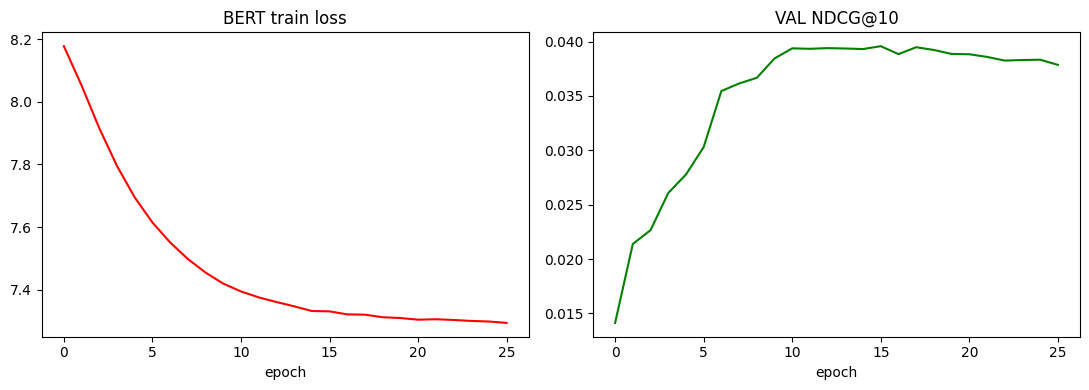

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["loss"], color="red"); ax[0].set_title("BERT train loss"); ax[0].set_xlabel("epoch")
ax[1].plot(hist["val"], color="green"); ax[1].set_title("VAL NDCG@10"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 5. Eval DCG tren TEST (long-term)

In [7]:
rk, rl = rank_bert(bert, users, target="test", K=20)
res_bert = agg(rk, rl)
json.dump(res_bert, open(os.path.join(HERE, "results_bert.json"), "w"), ensure_ascii=False, indent=2)
print(json.dumps(res_bert, ensure_ascii=False, indent=2))

{
  "DCG@5": 2.7358765769591313,
  "NDCG@5": 0.033440891929497694,
  "Recall@5": 0.011559793502951382,
  "DCG@10": 3.9998243473412214,
  "NDCG@10": 0.036677188071689605,
  "Recall@10": 0.022003764976911925,
  "DCG@20": 6.30178365826356,
  "NDCG@20": 0.04895766477125622,
  "Recall@20": 0.04764017065765571
}
